# REGRESIÓN LOGÍSTICA VS. LSTM VS. GRU


Vamos a desarrollar a continuación el análisis de un modelo de regresión logística frente a LSTM y a GRU. El objetivo de este modelo es clasificar si la volatilidad histórica del día t supera su media móvil de 30 días, lo que indica un régimen de alta volatilidad. Esto puede interesarnos a la hora de determinar si nos conviene o no vender nuestras participaciones.

Utilizaremos la libreria yfinance para obtener los datos, y nos quedaremos con los últimos 12 años de registros. El análisis y visualización de estos datos es idéntico al del notebook de la regresión lineal.

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

### Variabes consideradas 

**LogReturn** — Log-retorno diario:
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**VolHist** — Volatilidad histórica a 10 días:
$$\sigma_t^{(10)} = \text{std}\left(r_{t-9},\, r_{t-8},\, \ldots,\, r_t\right)$$

**VolSpike (target)** — Régimen de alta volatilidad:
$$y_t = \mathbf{1}\left[\sigma_t^{(10)} > \overline{\sigma}_{t}^{(30)}\right]$$
donde $\overline{\sigma}_{t}^{(30)}$ es la media móvil de 30 días de VolHist. 


La variable respuesta es Vol Spike → 1 (alta volatilidad) / 0 (baja volatilidad).

Podemos tener en cuenta una característica importante: periodos de alta volatilidad tienden a seguir a periodos de alta volatilidad. Las RNNs (LSTM, GRU) deberían capturar esta dependencia temporal mejor que la Regresión Logística, que trata cada observación de forma independiente.

In [12]:
ticker = '^GSPC'
start  = '2014-01-01'
end    = '2026-01-01'
tiempo = 30   # días de historia que recibe el modelo en cada secuencia

data_raw = yf.download(ticker,start=start,end=end)
data_raw.columns = data_raw.columns.get_level_values(0)
close = data_raw['Close'].dropna()

log_ret  = np.log(close / close.shift(1))
vol_hist = log_ret.rolling(10).std()

vol_ma30  = vol_hist.rolling(30).mean()
vol_spike = (vol_hist > vol_ma30).astype(float)

FEATURE_COLS = ['LogReturn','VolHist'] 
N_FEATURES   = len(FEATURE_COLS)

feat_df = pd.DataFrame({
    'LogReturn': log_ret,
    'VolHist'  : vol_hist,
    'VolSpike' : vol_spike,
}, index=close.index).dropna()

pct = feat_df['VolSpike'].mean() * 100
print(f'Registros: {len(feat_df)}  |  Alta vol (1): {pct:.1f}%  |  Baja vol (0): {100-pct:.1f}%')

[*********************100%***********************]  1 of 1 completed

Registros: 3008  |  Alta vol (1): 42.6%  |  Baja vol (0): 57.4%


Visualizamos la variable respuesta: la volatilidad histórica (azul) frente a su media móvil de 30 días (rojo). Las zonas sombreadas en verde corresponden a días de alta volatilidad. Se aprecia claramente el fenómeno del COVID en 2020.

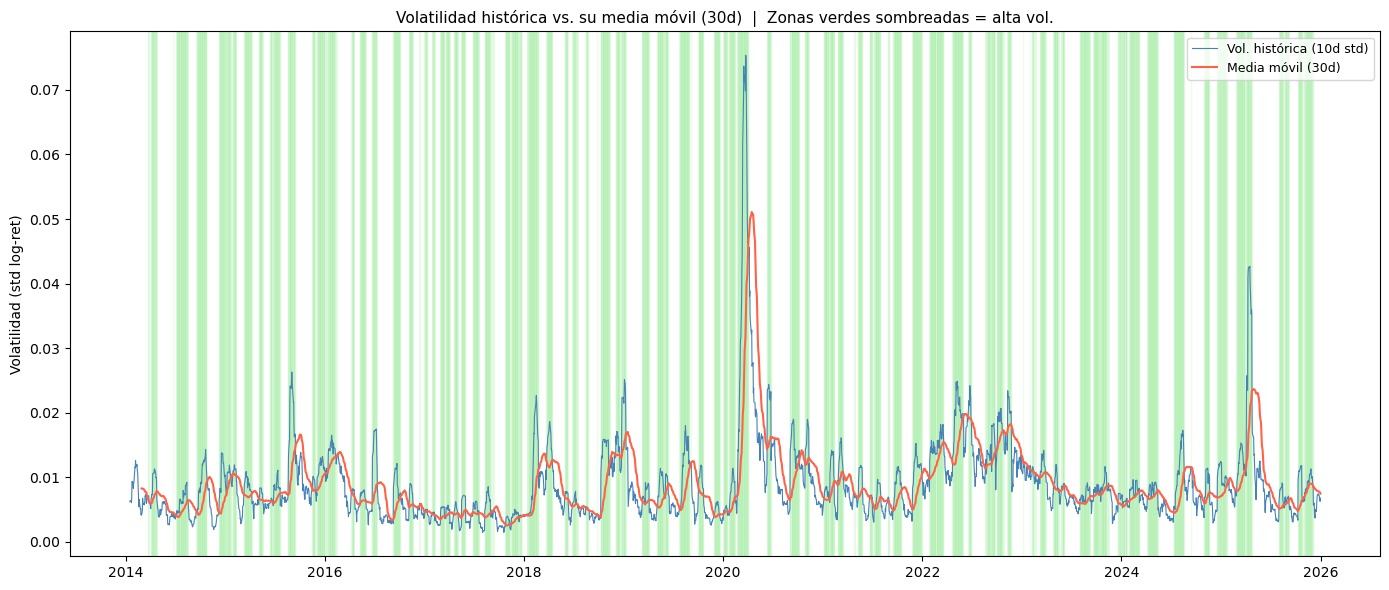

In [13]:
fig, ax = plt.subplots(figsize=(14, 6), sharex=True)

ax.plot(feat_df.index, feat_df['VolHist'], color='steelblue', lw=0.8, label='Vol. histórica (10d std)')
ax.plot(feat_df.index, vol_ma30.loc[feat_df.index], color='tomato', lw=1.5, label='Media móvil (30d)')
in_spike = feat_df['VolSpike'].values
for i in range(1, len(feat_df)):
    if in_spike[i] == 1:
        ax.axvspan(feat_df.index[i-1], feat_df.index[i], alpha=0.15, color='lightgreen')
ax.set_ylabel('Volatilidad (std log-ret)')
ax.set_title('Volatilidad histórica vs. su media móvil (30d)  |  Zonas verdes sombreadas = alta vol.', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Ahora vamos a construir las secuencias con las que entrenaremos los 3 modelos. Para cada día t, se construye una muestra formada por:

- **X**: matriz de dimensión (30 × 2) con los valores de las 2 features en los 30 días anteriores, es decir, los días `[t-30, t-1]`.
- **y**: valor del target en el día t (0 o 1).


**Observación sobre data leakage**: el target del día t depende de VolHist(t), que a su vez depende de los precios de los días `[t-9, t]`. La secuencia de entrada solo contiene datos hasta `t-1`, por lo que no existe acceso al valor que se predice*: no hay fuga de información.

Se utiliza una división estratificada 80 % train y 20 % test. La estratificación garantiza que la proporción de clases se mantiene igual en ambas particiones, lo que es especialmente importante cuando las clases no están perfectamente balanceadas (~57% baja vol, ~43% alta vol).

In [14]:
feat_arr = feat_df[FEATURE_COLS].values.astype(np.float32)
y_arr    = feat_df['VolSpike'].values.astype(np.float32)

X_list, y_list = [], []
for i in range(tiempo, len(feat_arr)):
    X_list.append(feat_arr[i - tiempo : i])
    y_list.append(y_arr[i])

X_raw = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list, dtype=np.float32)

print(f'X: {X_raw.shape}  ({len(X_raw)} secuencias × {tiempo} días × {N_FEATURES} features)')
print(f'y: {y_raw.shape}  —  alta vol (1): {y_raw.mean()*100:.1f}%')

X: (2978, 30, 2)  (2978 secuencias × 30 días × 2 features)
y: (2978,)  —  alta vol (1): 43.0%


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, shuffle=True, stratify=y_raw
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Alta vol — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Train: 2382  |  Test: 596
Alta vol — train: 43.0%  |  test: 43.0%


Podemos decir que un 43/57 es un buen balance de clases. Ahora hay que escalar: vamos a aplicar una normalización MinMax para llevar todos los valores al rango [0, 1]. El scaler se ajusta únicamente sobre el conjunto de entrenamiento y se aplica después al test, evitando filtrar información del futuro hacia el pasado.

In [16]:
scaler = MinMaxScaler()
scaler.fit(X_train.reshape(-1, N_FEATURES))

X_train_sc   = scaler.transform(X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
X_test_sc    = scaler.transform(X_test.reshape(-1,  N_FEATURES)).reshape(X_test.shape)
X_train_flat = X_train_sc.reshape(len(X_train_sc), -1)
X_test_flat  = X_test_sc.reshape(len(X_test_sc),  -1)

## Experimento 1: Regresión Logística

In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_flat, y_train)

y_pred_lr = logreg.predict(X_test_flat)
y_prob_lr = logreg.predict_proba(X_test_flat)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f'Reg. Logística — Accuracy: {acc_lr:.4f}  |  F1: {f1_lr:.4f}  |  AUC-ROC: {auc_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Baja vol', 'Alta vol']))

Reg. Logística — Accuracy: 0.8758  |  F1: 0.8471  |  AUC-ROC: 0.9435
              precision    recall  f1-score   support

    Baja vol       0.86      0.93      0.90       340
    Alta vol       0.90      0.80      0.85       256

    accuracy                           0.88       596
   macro avg       0.88      0.87      0.87       596
weighted avg       0.88      0.88      0.87       596



## Experimento 2: LSTM

La arquitectura utilizada es de dos capas apiladas: la primera capa  de 64 unidades y la segunda capa de 32 unidades. El dropout entre capas regulariza el modelo para evitar sobreajuste. Tanto LSTM como más adelante GRU usan EarlyStopping con `patience=15`: el entrenamiento se detiene si la pérdida de validación no mejora durante 15 épocas consecutivas, y se restauran los pesos del mejor momento.

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5669 - loss: 0.6807 - val_accuracy: 0.5220 - val_loss: 0.6969
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5900 - loss: 0.6629 - val_accuracy: 0.5954 - val_loss: 0.6541
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6115 - loss: 0.6396 - val_accuracy: 0.6373 - val_loss: 0.6374
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6598 - loss: 0.6293 - val_accuracy: 0.6583 - val_loss: 0.6225
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6766 - loss: 0.6156 - val_accuracy: 0.6709 - val_loss: 0.6074
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6824 - loss: 0.5986 - val_accuracy: 0.6981 - val_loss: 0.5863
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7013 - loss: 0.5774 - val_accuracy: 0.7191 - val_loss: 0.5708
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7029 - loss: 0.5629 - val_accuracy: 0.7212 - 

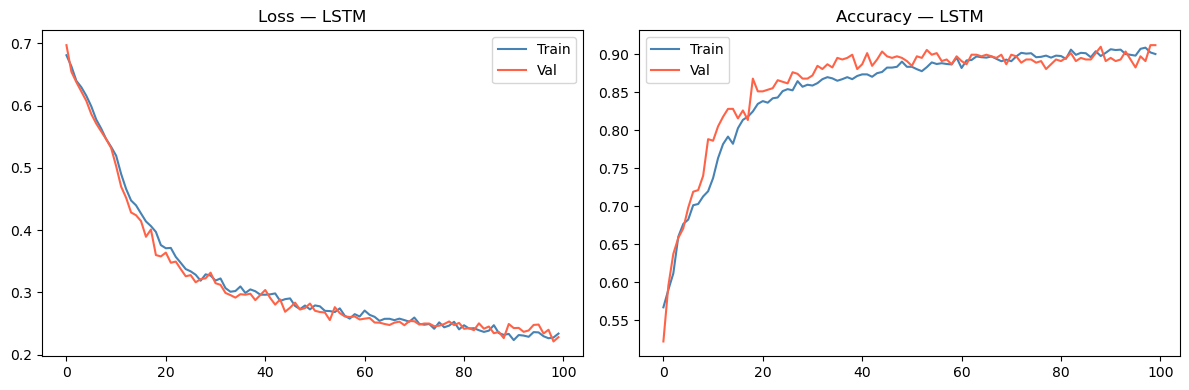

LSTM — Accuracy: 0.8809  |  F1: 0.8637  |  AUC-ROC: 0.9531
              precision    recall  f1-score   support

    Baja vol       0.91      0.88      0.89       340
    Alta vol       0.85      0.88      0.86       256

    accuracy                           0.88       596
   macro avg       0.88      0.88      0.88       596
weighted avg       0.88      0.88      0.88       596



In [18]:
lstm_model = Sequential([
    Input(shape=(tiempo, N_FEATURES)),
    LSTM(64, return_sequences=True), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                   loss='binary_crossentropy', metrics=['accuracy'])

early_stop_lstm=EarlyStopping(monitor='val_loss',patience=15, restore_best_weights=True, verbose=1)

history_lstm = lstm_model.fit(
    X_train_sc, y_train, epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[early_stop_lstm],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['loss'], label='Train', color='steelblue')
axes[0].plot(history_lstm.history['val_loss'], label='Val', color='tomato')
axes[0].set_title('Loss — LSTM'); axes[0].legend()
axes[1].plot(history_lstm.history['accuracy'], label='Train', color='steelblue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val', color='tomato')
axes[1].set_title('Accuracy — LSTM'); axes[1].legend()
plt.tight_layout()
plt.show()

y_prob_lstm = lstm_model.predict(X_test_sc, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_prob_lstm)
print(f'LSTM — Accuracy: {acc_lstm:.4f}  |  F1: {f1_lstm:.4f}  |  AUC-ROC: {auc_lstm:.4f}')
print(classification_report(y_test, y_pred_lstm, target_names=['Baja vol', 'Alta vol']))

## Experimento 3: GRU


La arquitectura es idéntica a la del LSTM (dos capas de 64 y 32 unidades con Dropout), lo que permite una comparación justa entre ambas.



Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5606 - loss: 0.6830 - val_accuracy: 0.5241 - val_loss: 0.6971
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5848 - loss: 0.6743 - val_accuracy: 0.5325 - val_loss: 0.6887
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5885 - loss: 0.6673 - val_accuracy: 0.5451 - val_loss: 0.6777
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6100 - loss: 0.6545 - val_accuracy: 0.6038 - val_loss: 0.6497
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6934 - loss: 0.5808 - val_accuracy: 0.7820 - val_loss: 0.5230
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7596 - loss: 0.4974 - val_accuracy: 0.8092 - val_loss: 0.4853
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7774 - loss: 0.4641 - val_accuracy: 0.8155 - val_loss: 0.4593
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7979 - loss: 0.4364 - val_accuracy: 0.8365 - 

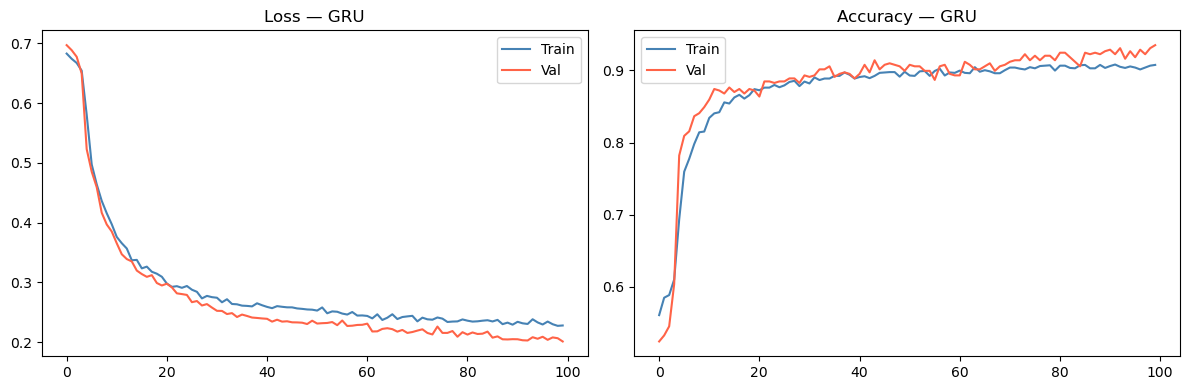

GRU  — Accuracy: 0.9161  |  F1: 0.9020  |  AUC-ROC: 0.9620
              precision    recall  f1-score   support

    Baja vol       0.92      0.93      0.93       340
    Alta vol       0.91      0.90      0.90       256

    accuracy                           0.92       596
   macro avg       0.91      0.91      0.91       596
weighted avg       0.92      0.92      0.92       596



In [19]:
gru_model = Sequential([
    Input(shape=(tiempo, N_FEATURES)),
    GRU(64, return_sequences=True), Dropout(0.2),
    GRU(32, return_sequences=False), Dropout(0.2),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])

early_stop_gru=EarlyStopping(monitor='val_loss',patience=15, restore_best_weights=True, verbose=1)


history_gru = gru_model.fit(
    X_train_sc, y_train, epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[early_stop_gru],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_gru.history['loss'], label='Train', color='steelblue')
axes[0].plot(history_gru.history['val_loss'], label='Val', color='tomato')
axes[0].set_title('Loss — GRU'); axes[0].legend()
axes[1].plot(history_gru.history['accuracy'], label='Train', color='steelblue')
axes[1].plot(history_gru.history['val_accuracy'], label='Val', color='tomato')
axes[1].set_title('Accuracy — GRU'); axes[1].legend()
plt.tight_layout()
plt.show()

y_prob_gru = gru_model.predict(X_test_sc, verbose=0).flatten()
y_pred_gru = (y_prob_gru >= 0.5).astype(int)
acc_gru = accuracy_score(y_test, y_pred_gru)
f1_gru  = f1_score(y_test, y_pred_gru)
auc_gru = roc_auc_score(y_test, y_prob_gru)
print(f'GRU  — Accuracy: {acc_gru:.4f}  |  F1: {f1_gru:.4f}  |  AUC-ROC: {auc_gru:.4f}')
print(classification_report(y_test, y_pred_gru, target_names=['Baja vol', 'Alta vol']))

## Comparación final

        Modelo  Accuracy  F1-Score  AUC-ROC
           GRU    0.9161    0.9020   0.9620
          LSTM    0.8809    0.8637   0.9531
Reg. Logística    0.8758    0.8471   0.9435


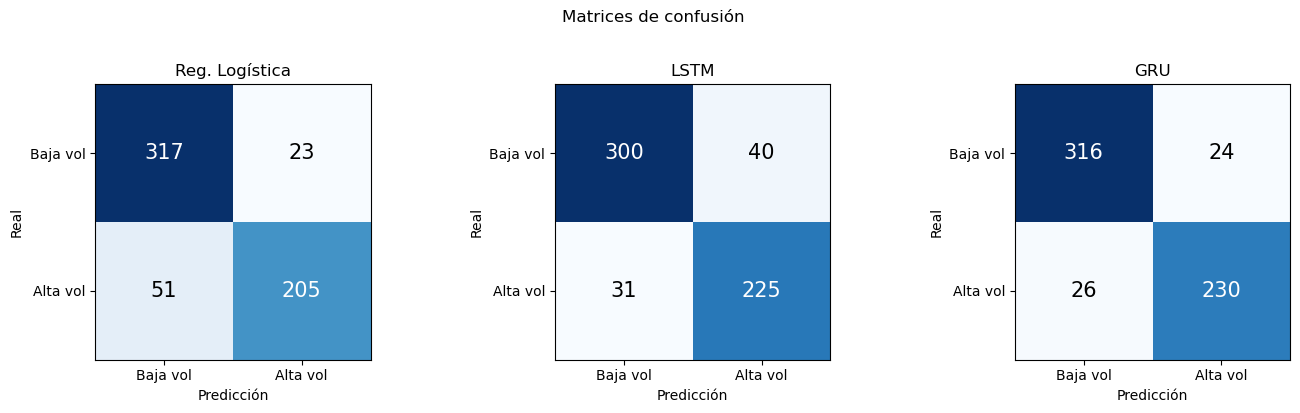

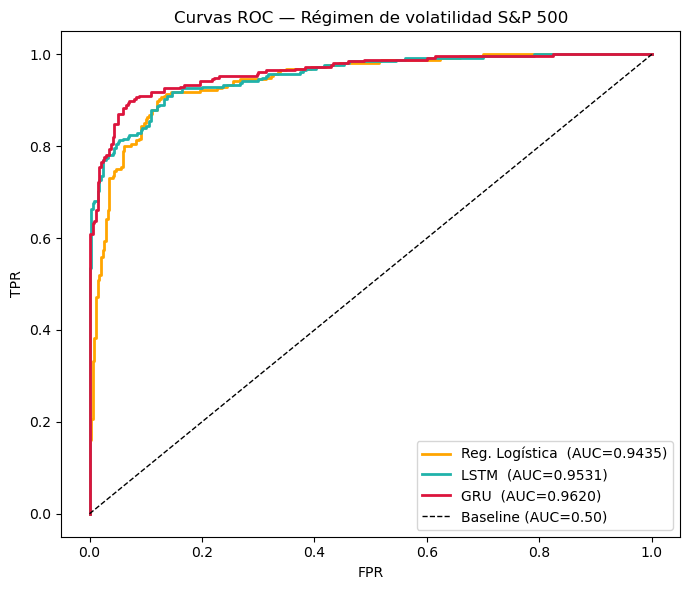

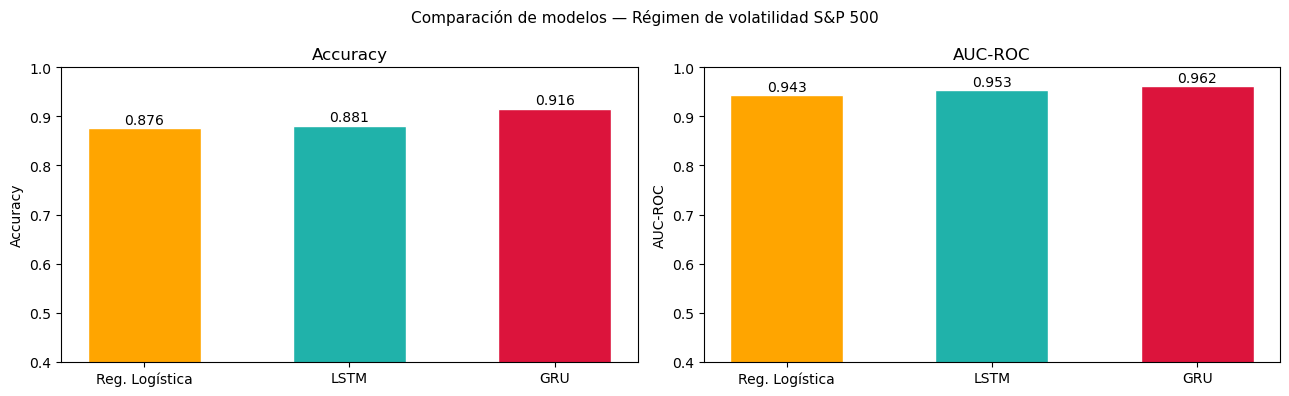

In [28]:

results = pd.DataFrame({
    'Modelo'  : ['Reg. Logística', 'LSTM', 'GRU'],
    'Accuracy': [acc_lr, acc_lstm, acc_gru],
    'F1-Score': [f1_lr,  f1_lstm,  f1_gru],
    'AUC-ROC' : [auc_lr, auc_lstm, auc_gru],
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(results.to_string(index=False, float_format='{:.4f}'.format))

# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, yp in zip(axes,
                        ['Reg. Logística', 'LSTM', 'GRU'],
                        [y_pred_lr, y_pred_lstm, y_pred_gru]):
    cm = confusion_matrix(y_test, yp)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Baja vol','Alta vol'], fontsize=10)
    ax.set_yticklabels(['Baja vol','Alta vol'], fontsize=10)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.set_title(name, fontsize=12)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=15,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.suptitle('Matrices de confusión', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, yprob, color in [('Reg. Logística', y_prob_lr, 'orange'),
                            ('LSTM', y_prob_lstm, 'lightseagreen'),
                            ('GRU',  y_prob_gru,  'crimson')]:
    fpr, tpr, _ = roc_curve(y_test, yprob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={roc_auc_score(y_test,yprob):.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Baseline (AUC=0.50)')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Régimen de volatilidad S&P 500', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# Barras AUC
fig, axes = plt.subplots(1,2,figsize=(13, 4))
modelos  = ['Reg. Logística', 'LSTM', 'GRU']
acc_vals = [acc_lr,  acc_lstm,  acc_gru]
auc_vals = [auc_lr, auc_lstm, auc_gru]
colors   = ['orange', 'lightseagreen', 'crimson']

bars = axes[0].bar(modelos, acc_vals, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0.40, 1); axes[0].set_title('Accuracy', fontsize=12)
axes[0].set_ylabel('Accuracy')

bars2 = axes[1].bar(modelos, auc_vals, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0.40, 1); axes[1].set_title('AUC-ROC', fontsize=12)
axes[1].set_ylabel('AUC-ROC')

plt.suptitle('Comparación de modelos — Régimen de volatilidad S&P 500', fontsize=11)
plt.tight_layout()
plt.show()

## Conclusiones

El buen comportamiento de la regresión logística sugiere que una parte importante de la información predictiva está contenida de forma aproximadamente lineal en las variables de entrada. Sin embargo, si miramos las matrices de confusión vemos que la regresión lineal comete precisamente el peor error (predecir que el mercado está en calma cuando no lo está)en más casos que los modelos de RNN. De hecho, también podemos ver este comportamiento en que el F1-Score de la regresión es significativamente más bajo que el de las RNN, lo cual muestra la superioridad de estas redes.

Las redes recurrentes LSTM y GRU, con mayor capacidad para capturar dependencias temporales no lineales, tienen margen para mejorar aún más estos resultados. La GRU se posiciona como el modelo más competitivo, superando tanto a la regresión logística como a la LSTM en todas las métricas, con un comportamiento especialmente equilibrado entre clases, lo cual es un muy bien indicador. La LSTM también logra superar a la regresión logística, aunque en menor medida que la GRU.

Todos los modelos alcanzan métricas elevadas, lo que demuestra que la historia reciente de la volatilidad contiene información predictiva de calidad sobre el estado futuro del mercado. Esto refuerza la importancia de la ingeniería de variables frente a la complejidad del modelo: una representación adecuada de los datos puede ser más determinante que la sofisticación arquitectónica.
